# Create table and txs

In [91]:
import os
import subprocess
import glob

# ------------------------------------------------------------------------------
# Configuration: Paths to the Python scripts (relative to the notebook)
# ------------------------------------------------------------------------------
py_gen_deltas_path = os.path.join("gen_py", "gen_deltas.py")           # Path to gen_tables.py
gen_inc_update_path = os.path.join("gen_py", "gen_inc_update.py")     # Path to gen_inc_update.py
gen_res_path = os.path.join("gen_py", "gen_res.py")                 # Path to gen_rec.py

# CSV folder is assumed to be at ../csv relative to the scripts
csv_dir = os.path.join(os.path.dirname(os.path.abspath(py_gen_deltas_path)), "..", "csv")
res_dir = os.path.join(os.path.dirname(os.path.abspath(py_gen_deltas_path)), "..", "csv", "res")

# ------------------------------------------------------------------------------
# 1) Delete existing CSV files in CSV folder
# ------------------------------------------------------------------------------
print(f"Deleting existing CSV files in: {csv_dir}")
if os.path.exists(csv_dir):
    for f in glob.glob(os.path.join(csv_dir, "*.csv")):
        os.remove(f)
    for f in glob.glob(os.path.join(res_dir, "*.csv")):
        os.remove(f)
    print("Old CSV files deleted.\n")
else:
    print("CSV folder does not exist. It will be created by the scripts.\n")

# ------------------------------------------------------------------------------
# 2) Run gen_tables.py to generate tables
# ------------------------------------------------------------------------------
cmd_tables = [
    "python3", py_gen_deltas_path,   # Run gen_tables.py using python3
    "-pknum", "10000",                  # unique pkey num
    "-jkps", "1000",                   # join key pool size
    "-jks",  "100",                     # join key num of bytes
    "-pks",  "8",                     # primary key size
    "-vpr", "10",                      # versions per unique row
    "-deltas", "10",                   # number of deltas
    "-minv",   "892",                   # min value size
    "-maxv",   "892",                   # max value size
    "-scanjkn", "1000",
]

print("Running gen_deltas.py with command:")
print(" ".join(cmd_tables), "\n")
result_tables = subprocess.run(cmd_tables, capture_output=True, text=True)
print("gen_tables.py STDOUT:")
print(result_tables.stdout)
print("gen_tables.py STDERR:")
print(result_tables.stderr)




Deleting existing CSV files in: ./benches/hash_join/bench_join_simulation_repair/gen_py/../csv
Old CSV files deleted.

Running gen_deltas.py with command:
python3 gen_py/gen_deltas.py -pknum 10000 -jkps 1000 -jks 100 -pks 8 -vpr 10 -deltas 10 -minv 892 -maxv 892 -scanjkn 1000 

gen_tables.py STDOUT:
Generating a join key pool of size 1000 (each key length = 100) ...
  -> ./benches/hash_join/bench_join_simulation_repair/gen_py/../csv/key_pool.csv (contains 1000 keys).
Generating ./benches/hash_join/bench_join_simulation_repair/gen_py/../csv/table_deltas.csv with 10000 rows each of which has 10 versions...
  -> ./benches/hash_join/bench_join_simulation_repair/gen_py/../csv/table_deltas.csv generated.
Generating ./benches/hash_join/bench_join_simulation_repair/gen_py/../csv/join_keys_history.csv, ./benches/hash_join/bench_join_simulation_repair/gen_py/../csv/join_keys_recent.csv with 1000 rows...
  -> ./benches/hash_join/bench_join_simulation_repair/gen_py/../csv/join_keys_history.csv, ./

# Run join_simulation.rs

=== Building Rust binary in release mode ===
Cargo build completed successfully.


=== hash_type=heap-no_repair ===
   iteration 1/1
['./target/release/join_simulation_repair', '--csv-dir', './benches/hash_join/bench_join_simulation_repair/csv', '--deltas', 'table_deltas.csv', '--join-keys_prefix', 'join_keys', '-t', 'heap', '-rp', 'no_repair']

=== hash_type=heap-write_repair ===
   iteration 1/1
['./target/release/join_simulation_repair', '--csv-dir', './benches/hash_join/bench_join_simulation_repair/csv', '--deltas', 'table_deltas.csv', '--join-keys_prefix', 'join_keys', '-t', 'heap', '-rp', 'write_repair']

=== hash_type=heap-read_repair ===
   iteration 1/1
['./target/release/join_simulation_repair', '--csv-dir', './benches/hash_join/bench_join_simulation_repair/csv', '--deltas', 'table_deltas.csv', '--join-keys_prefix', 'join_keys', '-t', 'heap', '-rp', 'read_repair']

=== hash_type=ts_partition-no_repair ===
   iteration 1/1
['./target/release/join_simulation_repair', '--csv-dir

/tmp/ipykernel_3621/1383598620.py:167: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


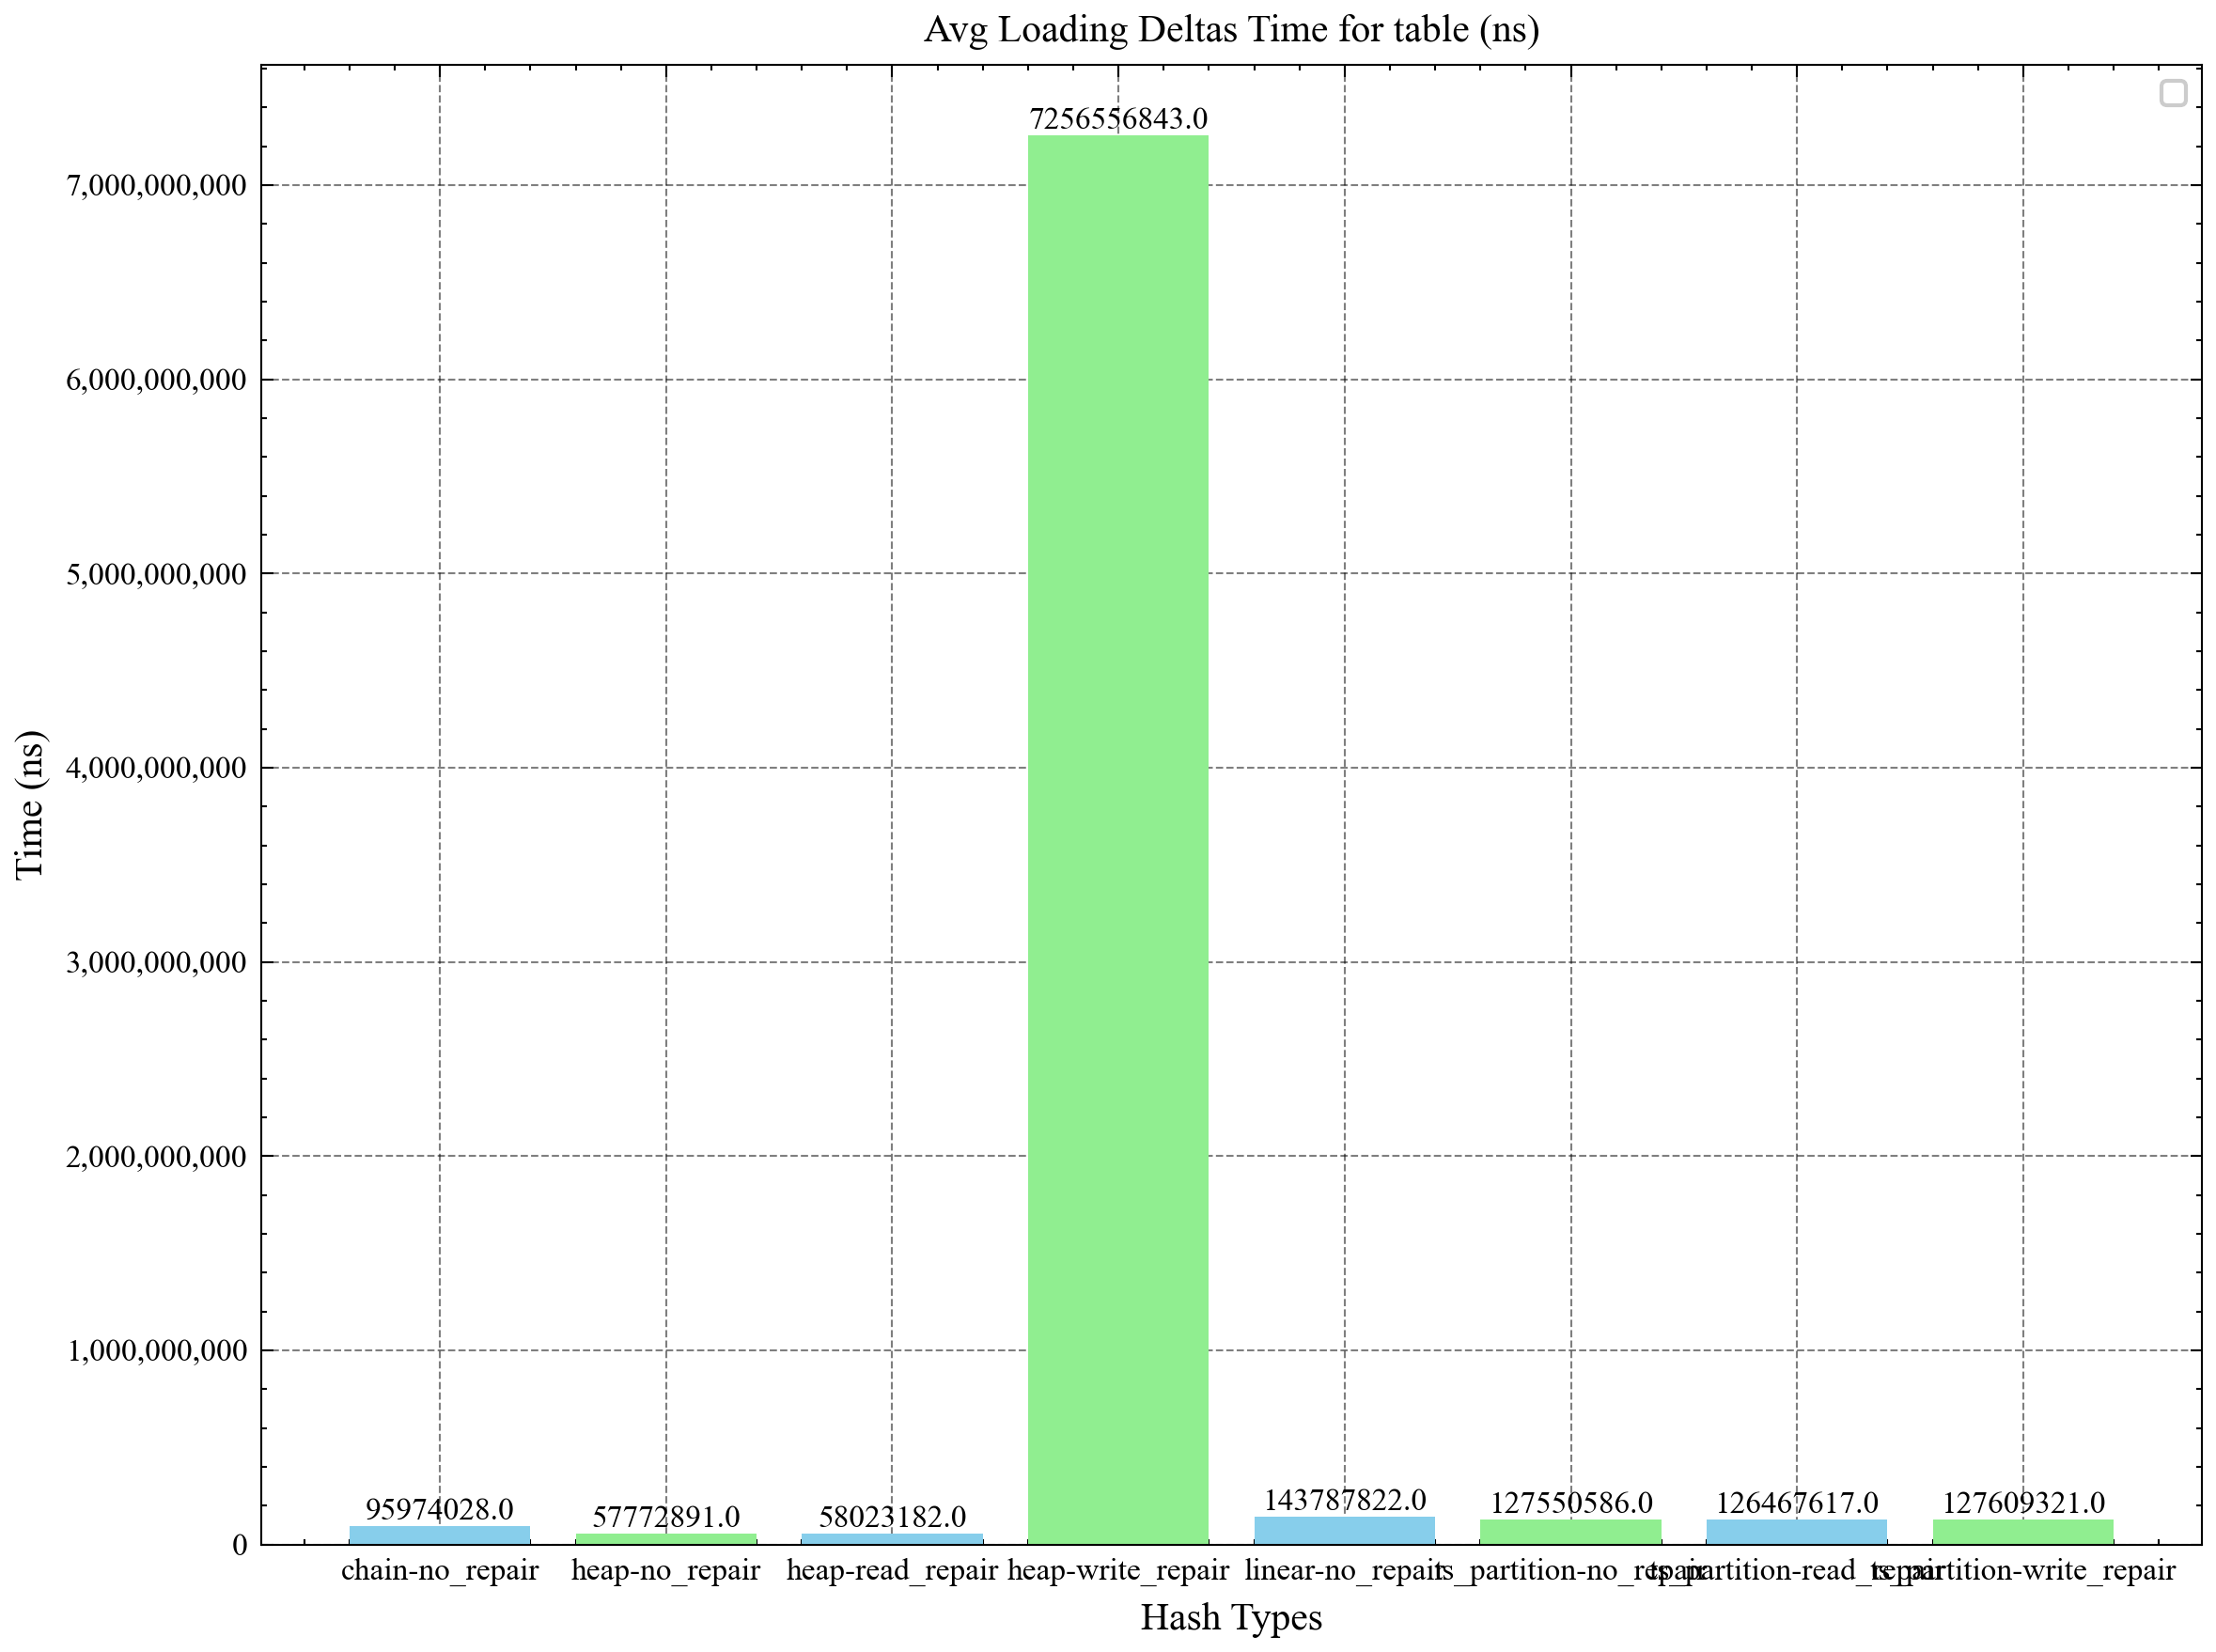

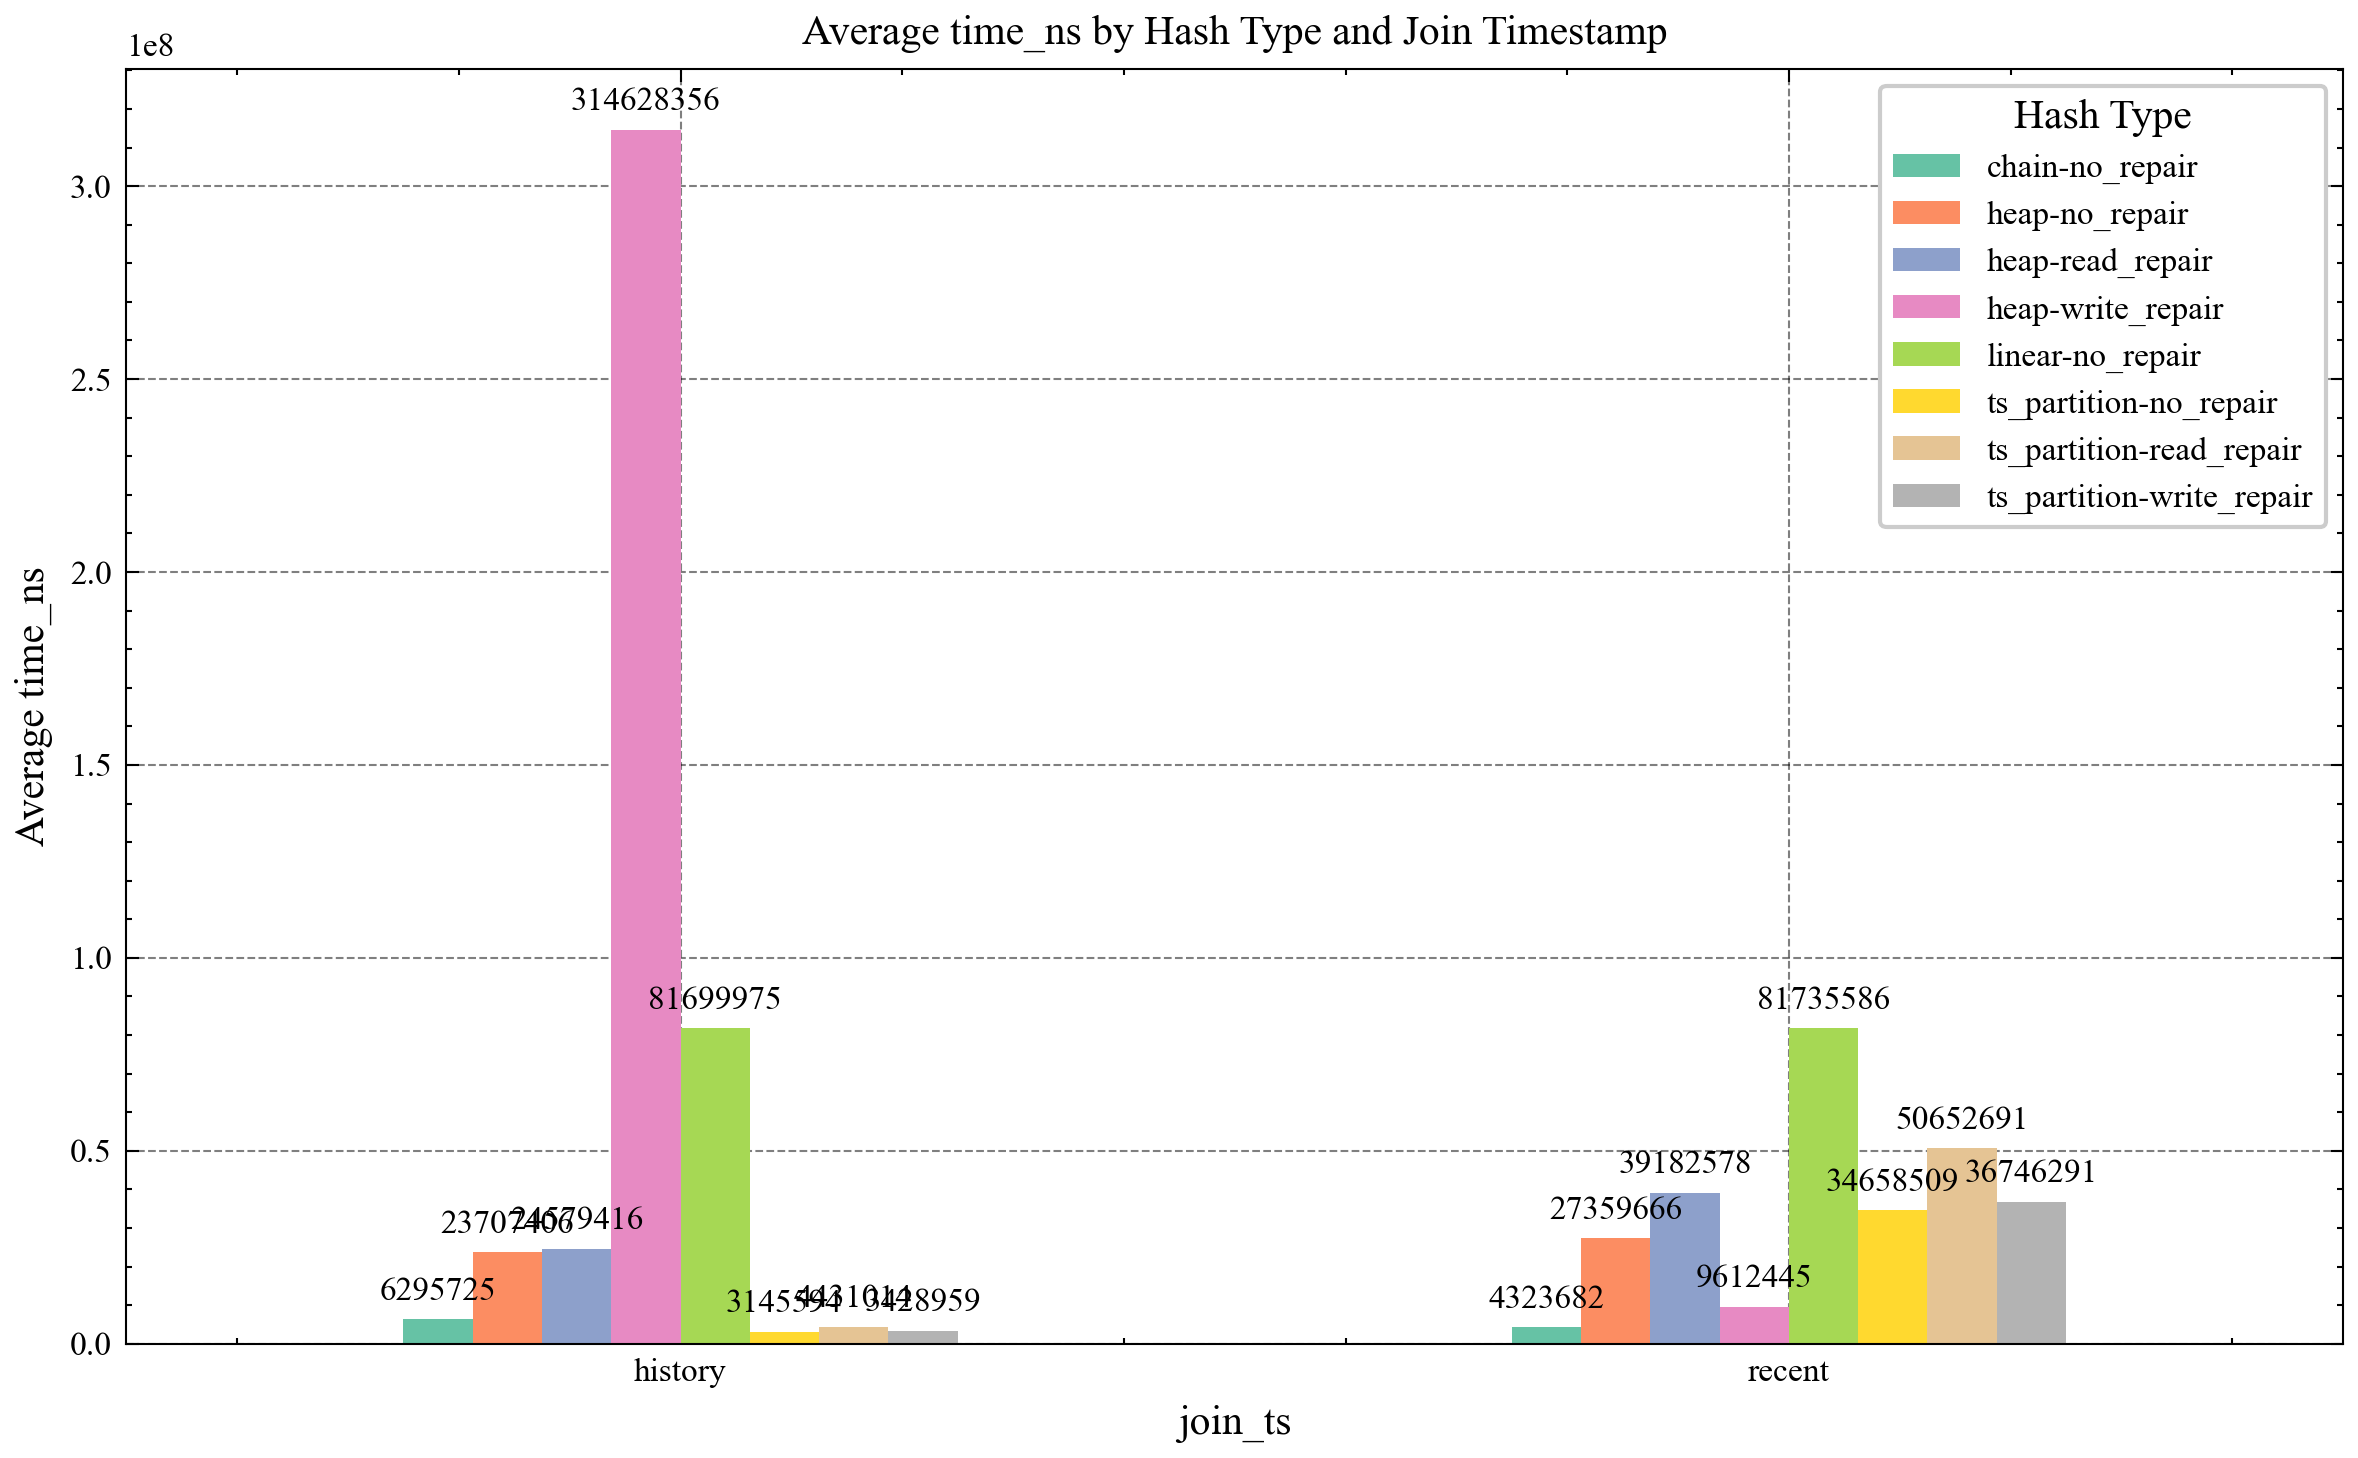

In [2]:
import subprocess
import re
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

###############################################################################
# 1) Configuration
###############################################################################

DEFAULT_BIN_NAME = "join_simulation_repair"
DEFAULT_NUM_ITERATIONS = 1 # how many times to repeat each coverage+hash run
hash_types = ["heap-no_repair", "heap-write_repair", "heap-read_repair", "ts_partition-no_repair", "ts_partition-write_repair", "ts_partition-read_repair",
              "linear-no_repair", "chain-no_repair"]  # which hash table types to test

# The directory containing "table_0.csv", "txs_...", etc.
csv_dir = os.path.abspath("csv")  
join_key_prefix = "join_keys"


# Use the custom style
plt.style.use('../custom_plt_sytle.mplstyle')

###############################################################################
# 2) Build the Rust binary
###############################################################################
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", DEFAULT_BIN_NAME]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")

###############################################################################
# 3) Discover coverage logs in the CSV directory
###############################################################################
if not os.path.exists(csv_dir):
    print(f"[ERROR] CSV folder not found: {csv_dir}")
    raise SystemExit(1)

all_files = os.listdir(csv_dir)


###############################################################################
# 4) Path to the Rust binary
###############################################################################
binary_path = os.path.abspath(
    os.path.join("..", "..", "..", "target", "release", DEFAULT_BIN_NAME)
)
if not os.path.exists(binary_path):
    print(f"[ERROR] Binary not found at: {binary_path}")
    raise SystemExit(1)

###############################################################################
# 5) Regex for parsing stdout lines
###############################################################################

applied_re = re.compile(r'^Applied\s+all\s+deltas\s+with\s+op\s+count.*?(\d+)\s*ns.*$')
history_join_re = re.compile(r'^\[test_name:\s+\"history_scan_keys\"\].*?(\d+)\s*ns.*$')
recent_join_re = re.compile(r'^\[test_name:\s+\"recent_scan_keys\"\].*?(\d+)\s*ns.*$')

###############################################################################
# 6) Data structures to hold parse results
###############################################################################
delta_rows   = []  # each row => {hash_type, time_ns_per_row}
join_key_rows = []  # each row => {hash_type, time_ns_per_op, 'history'/'recent'}


###############################################################################
# 7) Main loop: coverage × hash_types
###############################################################################
num_iterations = DEFAULT_NUM_ITERATIONS

for ht in hash_types:
    ht_binary_argu, repair_type_str = ht.split('-', 1)


    print(f"\n=== hash_type={ht} ===")


    # For join logs, store (time_sum, op_sum) keyed by (table_idx, ts_val)
    for iteration in range(num_iterations):
        print(f"   iteration {iteration+1}/{num_iterations}")

        cmd = [
            binary_path,
            "--csv-dir", csv_dir,
            "--deltas", "table_deltas.csv",
            "--join-keys_prefix", join_key_prefix,
            "-t", ht_binary_argu,
            "-rp", repair_type_str,
        ]
        
        proc = subprocess.run(cmd, capture_output=True, text=True)
        print(cmd)
        if proc.returncode != 0:
            print(f"[ERROR] type={ht}, iteration={iteration+1}")
            print(proc.stderr)
            continue
        
        # Parse stdout line by line
        stdout_lines = proc.stdout.splitlines()
        stdout_txt = '\n'.join(stdout_lines)
        # print(f"[stderr] {proc.stderr}")
        for line in stdout_lines:
            m_applied = applied_re.search(line)
            if m_applied:
                time_ns = int(m_applied.group(1))
                delta_rows.append({
                    "hash_type": ht,
                    "time_ns": time_ns,
                })
            m_recent_join = recent_join_re.search(line)
            if m_recent_join:
                time_ns = int(m_recent_join.group(1))
                join_key_rows.append({
                    "hash_type": ht,
                    "time_ns": time_ns,
                    "join_ts": 'recent',
                })
            m_history_join = history_join_re.search(line)
            if m_history_join:
                time_ns = int(m_history_join.group(1))
                join_key_rows.append({
                    "hash_type": ht,
                    "time_ns": time_ns,
                    "join_ts": 'history',
                })

###############################################################################
# 8) Convert to DataFrames
###############################################################################
delta_df = pd.DataFrame(delta_rows)
join_key_df = pd.DataFrame(join_key_rows)


print("\n=== Delta DF ===")
print(delta_df)

print("\n=== Join Key DF ===")
print(join_key_df)

###############################################################################
# 9) Define Delta Loading Bar Plot
###############################################################################
if not delta_df.empty:
    plt.figure(figsize=(8,6))

    # We'll create a nice y-axis formatter with comma grouping
    y_fmt = ticker.StrMethodFormatter('{x:,.0f}')
    plt.gca().yaxis.set_major_formatter(y_fmt)

    # Group and aggregate
    grouped = delta_df.groupby(['hash_type'])['time_ns'].mean().reset_index()
    bars = plt.bar(grouped['hash_type'], grouped['time_ns'], color=['skyblue', 'lightgreen'])
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height + 1000,  # 1000 for spacing
                f'{height:.1f}', ha='center', va='bottom')
    plt.title("Avg Loading Deltas Time for table (ns)")
    plt.xlabel("Hash Types")
    plt.ylabel("Time (ns)")
    plt.legend()
    plt.tight_layout()
    plt.show()


###############################################################################
# 10) Define Join Bar Plot
###############################################################################

# Group by (hash_type, join_ts) and calculate average
grouped = join_key_df.groupby(['hash_type', 'join_ts'])['time_ns'].mean().reset_index()

# Pivot to get suitable format for bar plot
pivot_df = grouped.pivot(index='join_ts', columns='hash_type', values='time_ns')

# Plot
ax = pivot_df.plot(kind='bar', figsize=(8, 5), colormap='Set2')
plt.ylabel('Average time_ns')
plt.title('Average time_ns by Hash Type and Join Timestamp')
plt.xticks(rotation=0)
plt.legend(title='Hash Type')

# Add exact values above each bar
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3621/3710948260.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


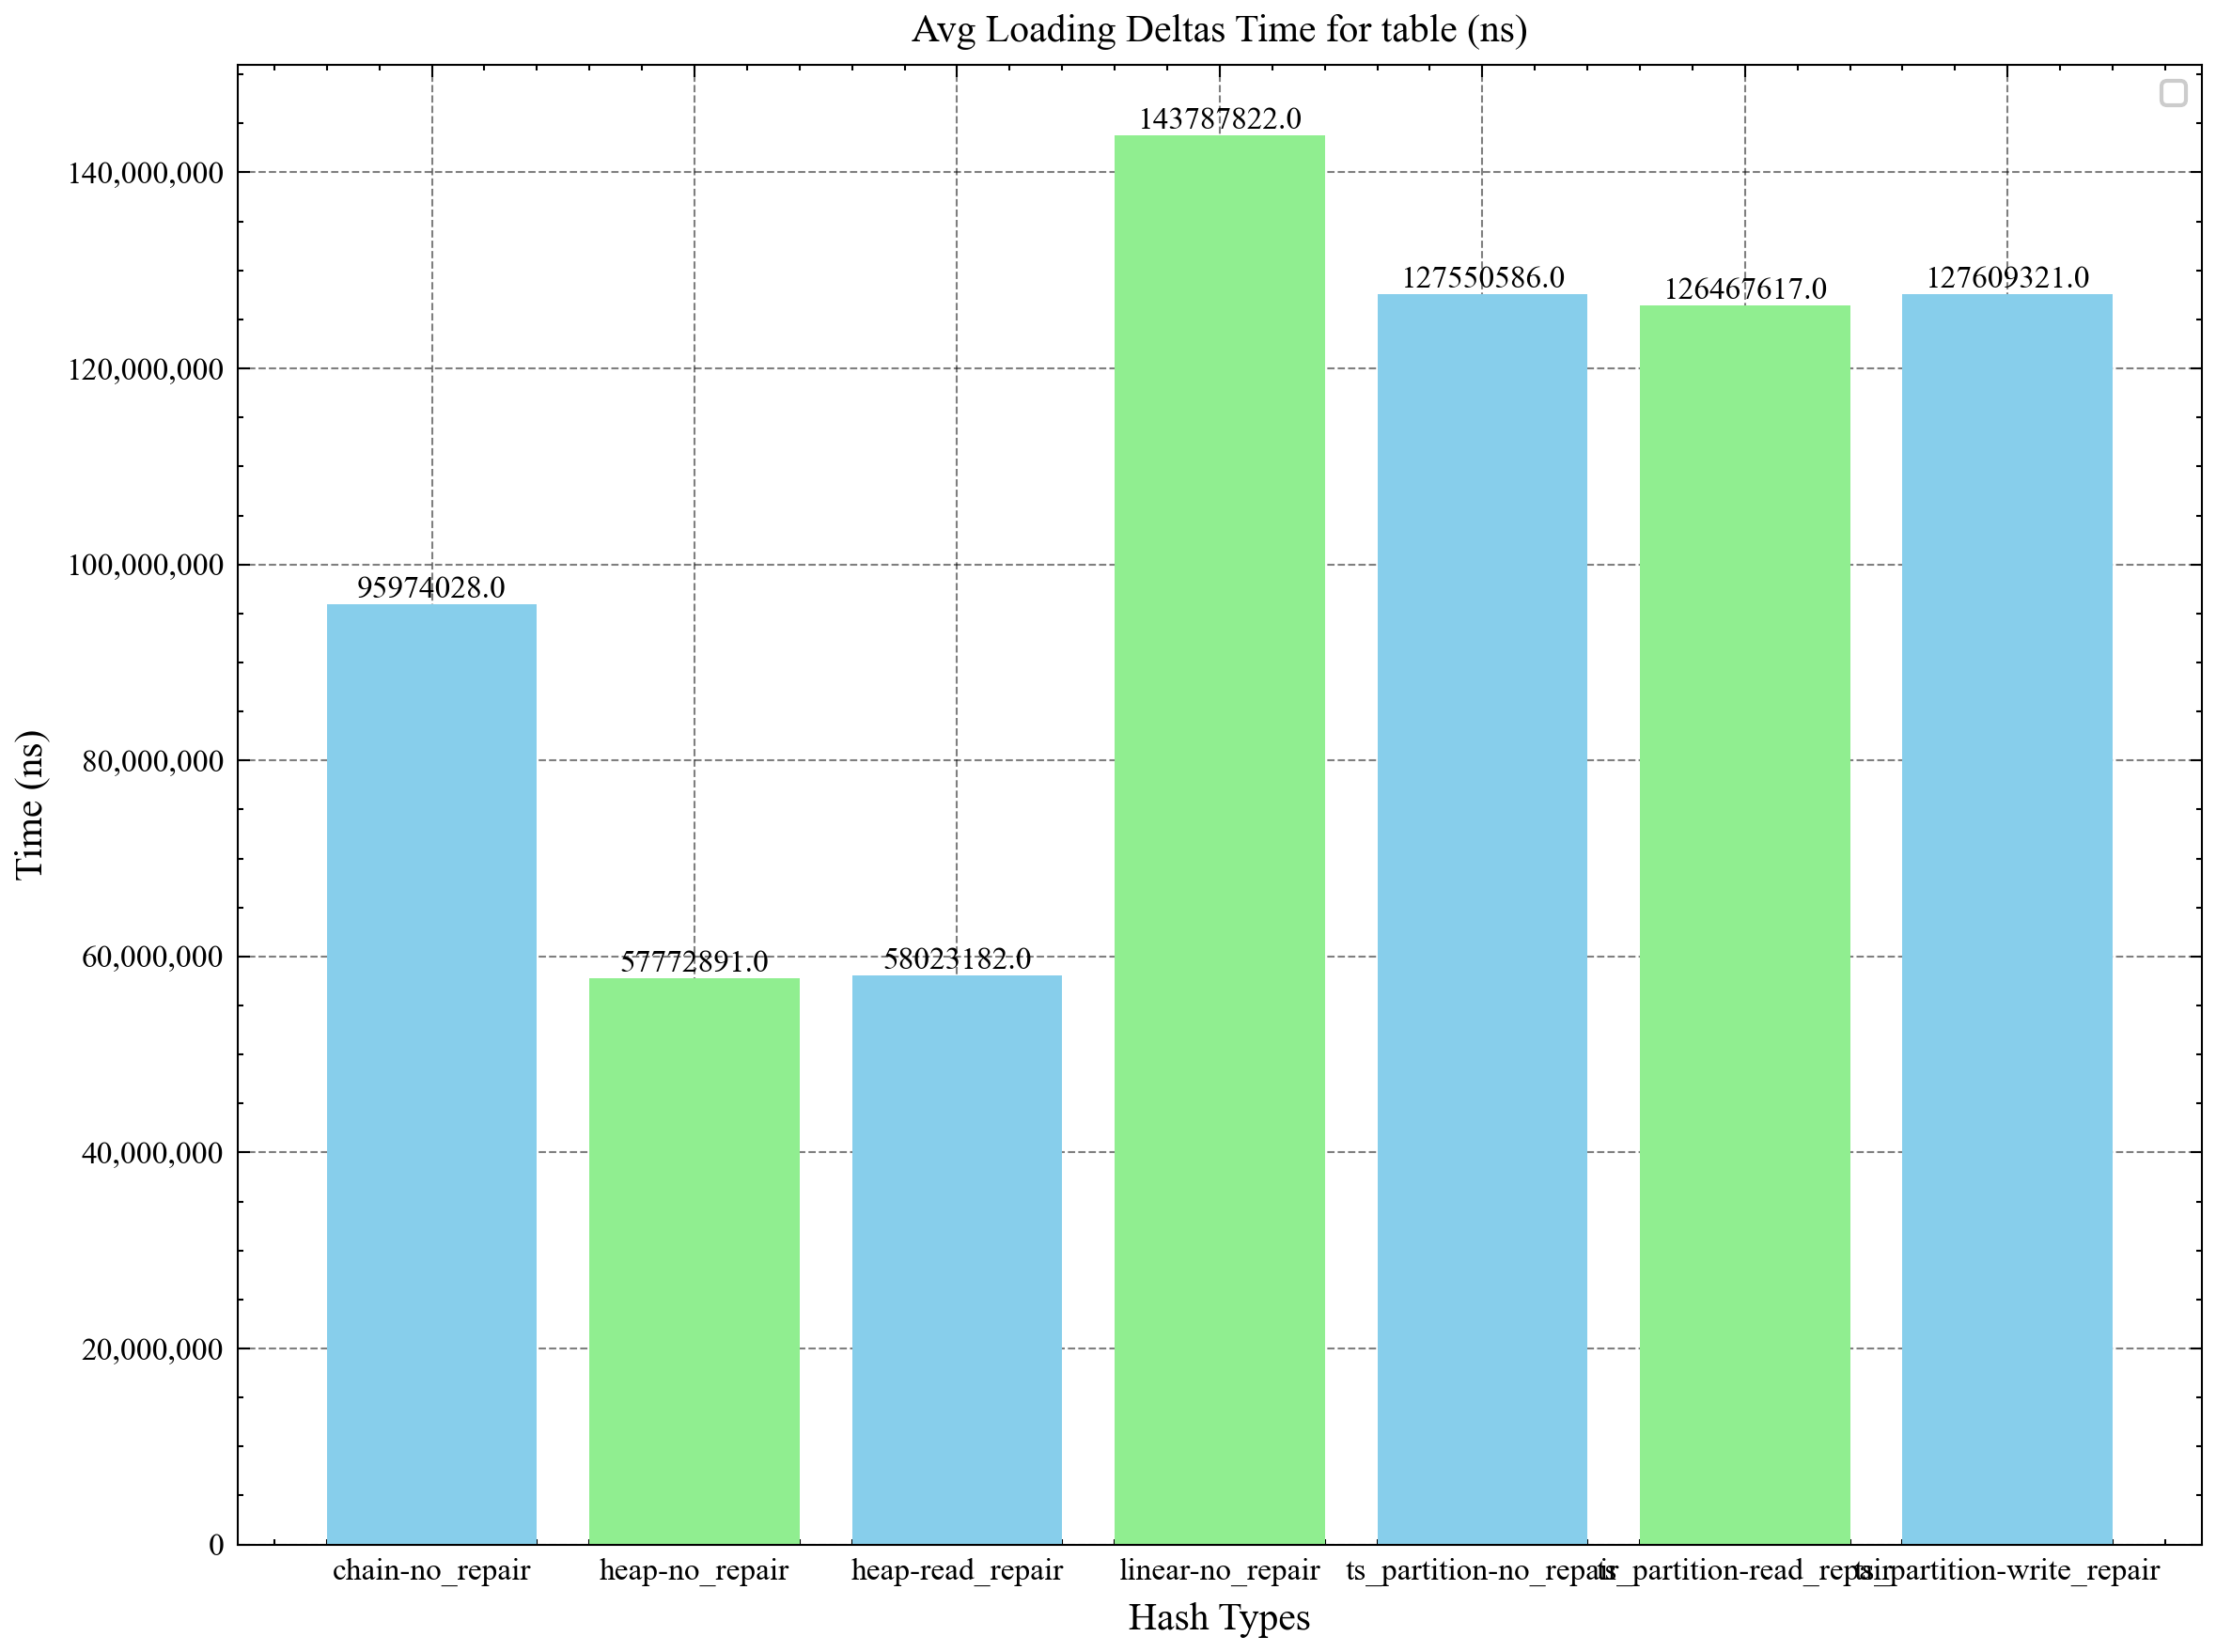

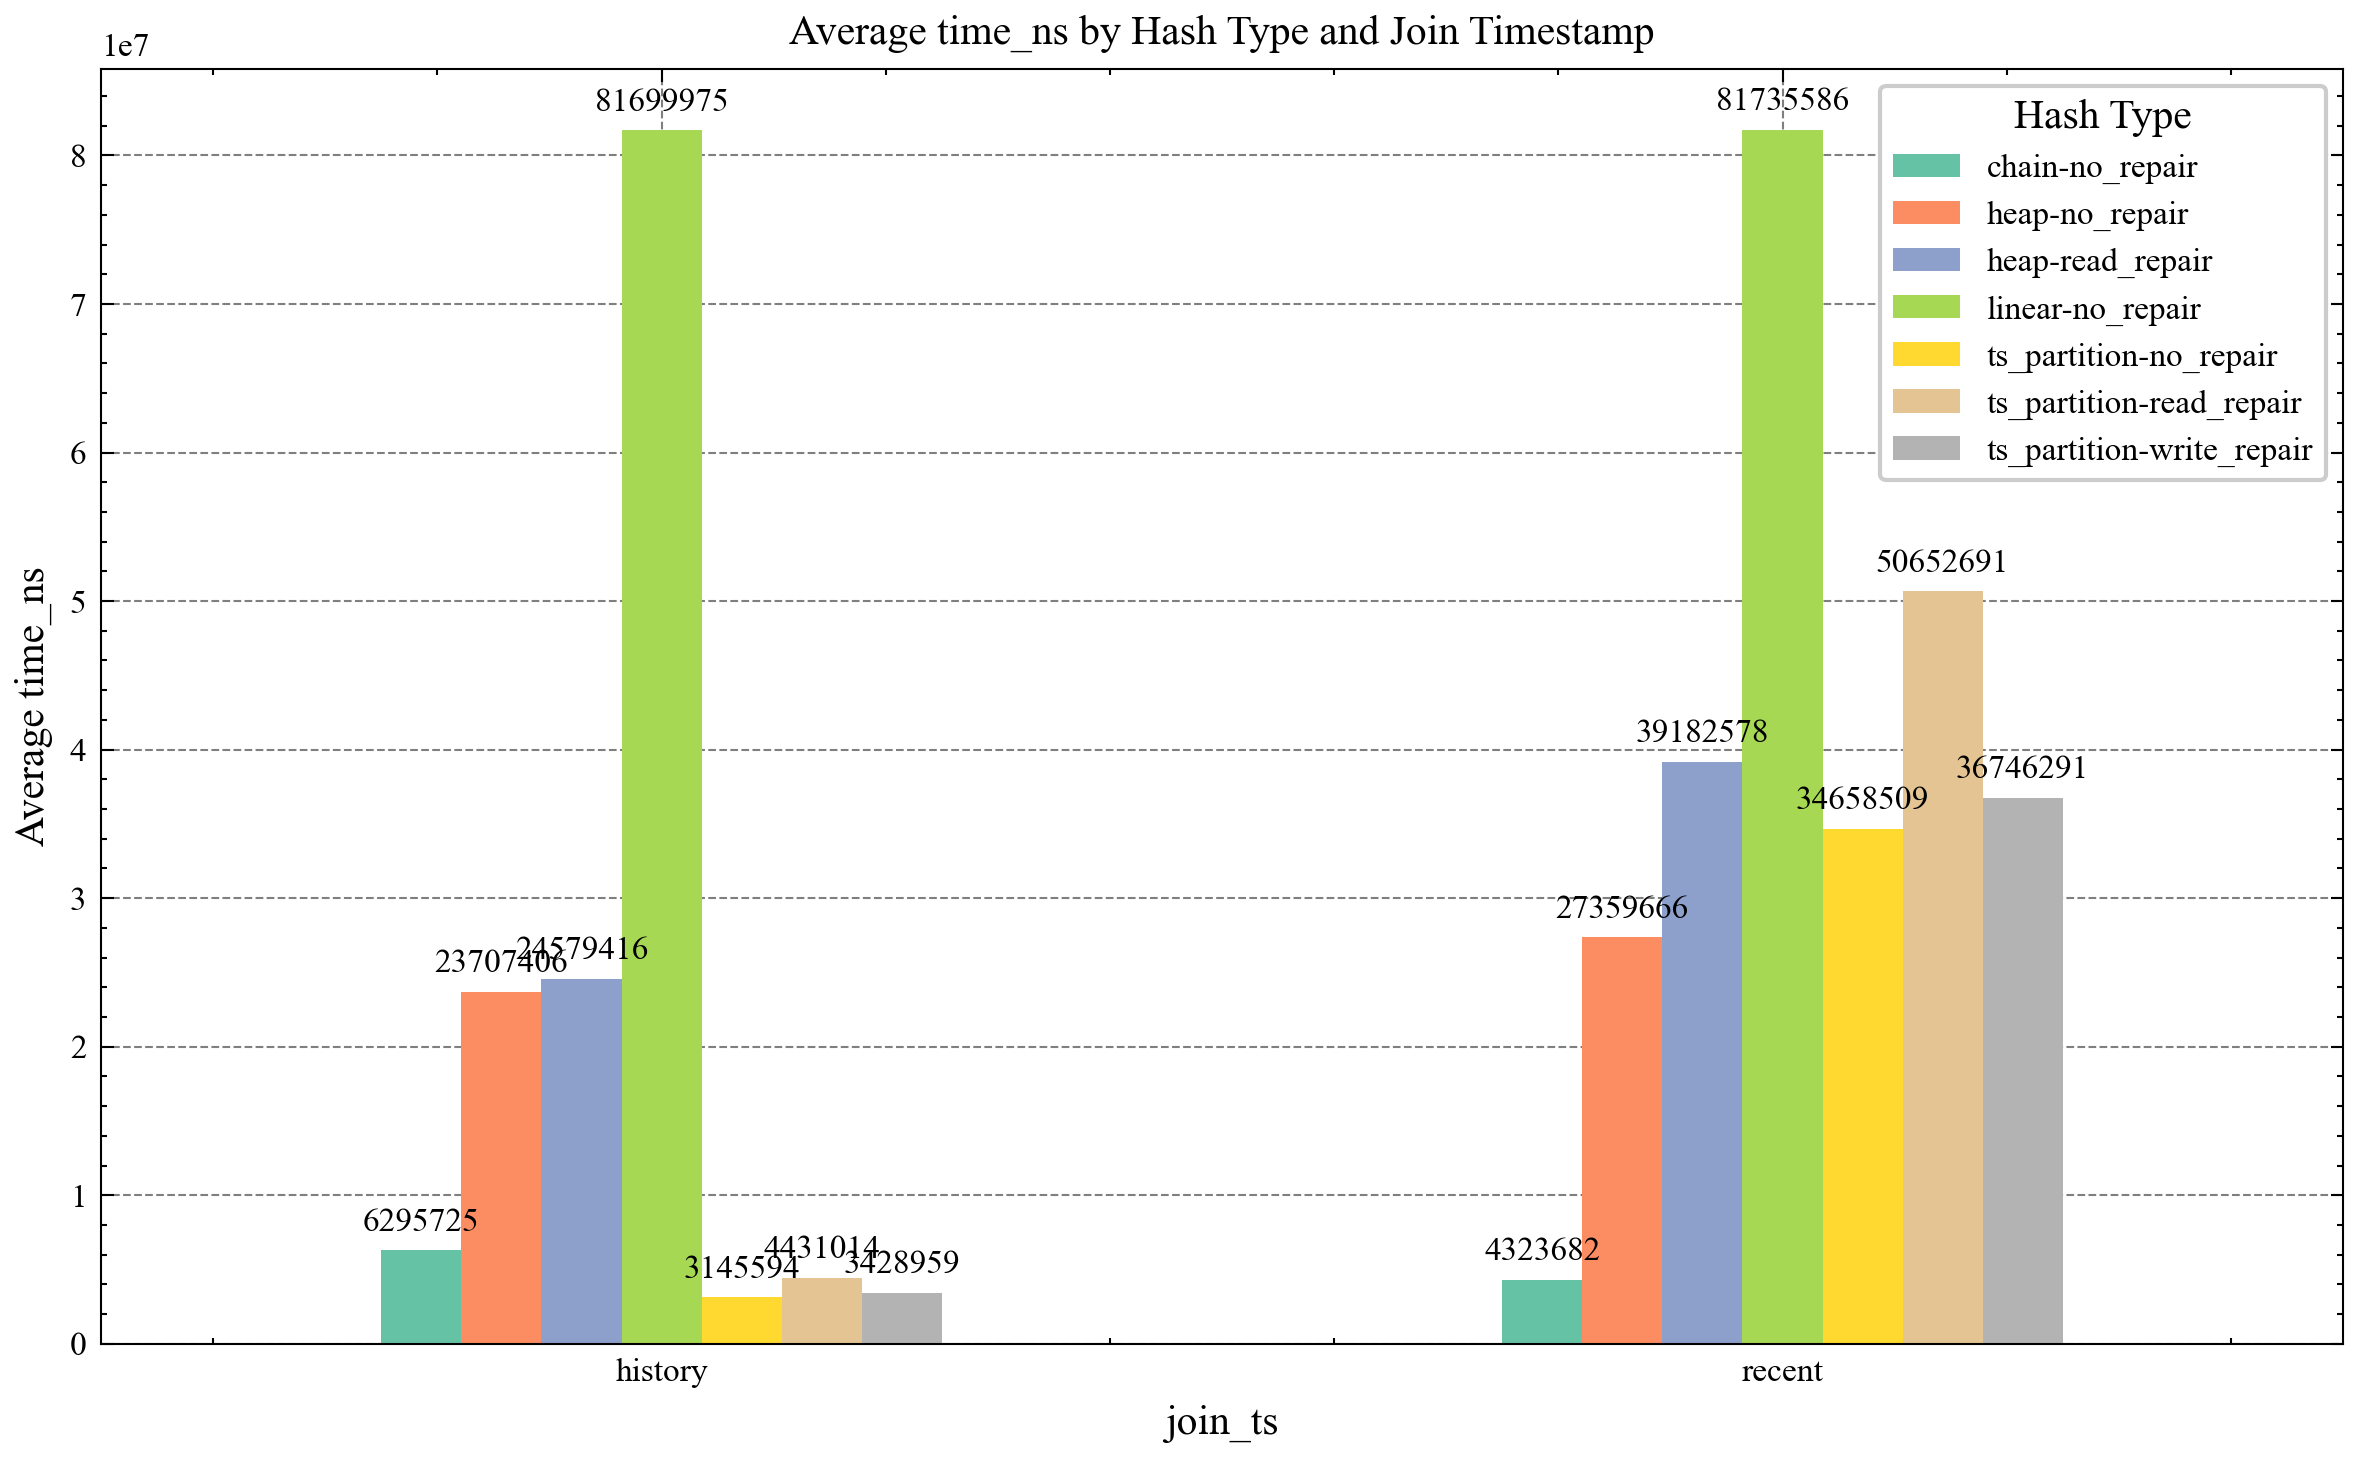

In [3]:
exclude = ['heap-write_repair']
new_delta_df = delta_df[~delta_df['hash_type'].isin(exclude)]
new_join_key_df = join_key_df[~join_key_df['hash_type'].isin(exclude)]

###############################################################################
# 9) Define Delta Loading Bar Plot
###############################################################################
plt.figure(figsize=(8,6))

# We'll create a nice y-axis formatter with comma grouping
y_fmt = ticker.StrMethodFormatter('{x:,.0f}')
plt.gca().yaxis.set_major_formatter(y_fmt)

# Group and aggregate
grouped = new_delta_df.groupby(['hash_type'])['time_ns'].mean().reset_index()
bars = plt.bar(grouped['hash_type'], grouped['time_ns'], color=['skyblue', 'lightgreen'])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1000,  # 1000 for spacing
            f'{height:.1f}', ha='center', va='bottom')
plt.title("Avg Loading Deltas Time for table (ns)")
plt.xlabel("Hash Types")
plt.ylabel("Time (ns)")
plt.legend()
plt.tight_layout()
plt.show()


###############################################################################
# 10) Define Join Bar Plot
###############################################################################

# Group by (hash_type, join_ts) and calculate average
grouped = new_join_key_df.groupby(['hash_type', 'join_ts'])['time_ns'].mean().reset_index()

# Pivot to get suitable format for bar plot
pivot_df = grouped.pivot(index='join_ts', columns='hash_type', values='time_ns')

# Plot
ax = pivot_df.plot(kind='bar', figsize=(8, 5), colormap='Set2')
plt.ylabel('Average time_ns')
plt.title('Average time_ns by Hash Type and Join Timestamp')
plt.xticks(rotation=0)
plt.legend(title='Hash Type')

# Add exact values above each bar
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()